In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
#making a noisy 'sin' wave
X = np.sort(10 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel() + np.random.randn(100) * 0.5  # .ravel() makes it a 1D array {signal+noise}

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
#Building the SVR Pipeline...
#SVR is extremely sensitive to scale, so StandardScaler is a must.
pipe_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf')) # Using the RBF kernel
])

In [6]:
# We need to tune C, gamma, AND epsilon
param_grid = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__gamma': [1, 0.1, 0.01],
    'svr__epsilon': [1, 0.5, 0.1, 0.01] # The width of the "tube"
}

In [7]:
#running GridSearchCV
#We use 'neg_mean_squared_error' because grid search tries to MAXIMIZE a score.
#By 'negating' MSE, a smaller error (e.g., -5) is "bigger" than a large error (e.g., -20).
grid_search = GridSearchCV(
    pipe_svr,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1
)

In [8]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svr', SVR())]),
             param_grid={'svr__C': [0.1, 1, 10, 100],
                         'svr__epsilon': [1, 0.5, 0.1, 0.01],
                         'svr__gamma': [1, 0.1, 0.01]},
             scoring='neg_mean_squared_error', verbose=1)

In [9]:
print("\n--- Grid Search Results ---")
print(f"Best parameters found: {grid_search.best_params_}")


--- Grid Search Results ---
Best parameters found: {'svr__C': 10, 'svr__epsilon': 0.5, 'svr__gamma': 1}


In [10]:
best_svr = grid_search.best_estimator_

In [11]:
y_pred = best_svr.predict(X_test)
final_mse = mean_squared_error(y_test, y_pred)
print(f"\nFinal Test Set RMSE: {np.sqrt(final_mse):.4f}")


Final Test Set RMSE: 0.5323


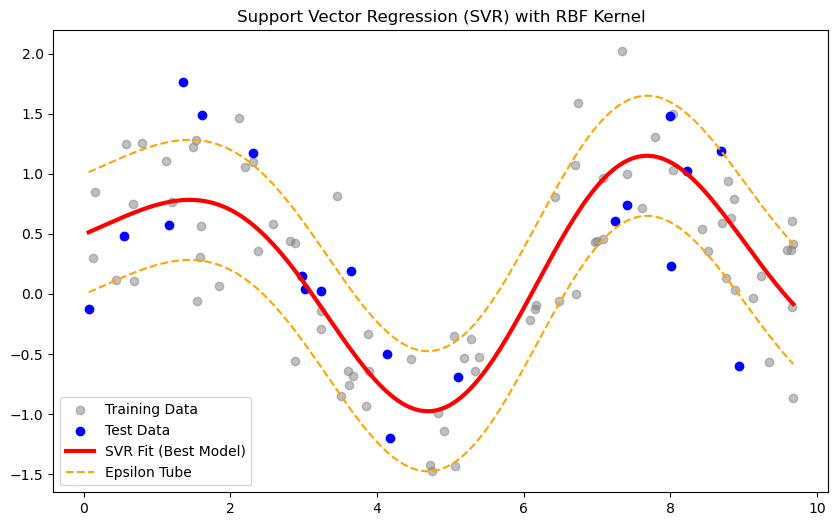

In [12]:
#plotting the results
X_plot = np.linspace(min(X), max(X), 200) # Create smooth line for plotting
y_plot = best_svr.predict(X_plot)
# We also want to see the 'tube' (epsilon)
epsilon = grid_search.best_params_['svr__epsilon']

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, c='gray', label='Training Data', alpha=0.5)
plt.scatter(X_test, y_test, c='blue', label='Test Data')
plt.plot(X_plot, y_plot, color='red', linewidth=3, label='SVR Fit (Best Model)')

# Plot the epsilon tube
plt.plot(X_plot, y_plot + epsilon, color='orange', linestyle='--', label='Epsilon Tube')
plt.plot(X_plot, y_plot - epsilon, color='orange', linestyle='--')

plt.title("Support Vector Regression (SVR) with RBF Kernel")
plt.legend()
plt.show()